In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
base = '/content/drive/MyDrive/proyecto_reciclaje'
for carpeta in ['organico', 'reciclable', 'no_reciclable']:
    ruta = os.path.join(base, carpeta)
    print(carpeta, '→', len(os.listdir(ruta)), 'fotos')

organico → 15 fotos
reciclable → 15 fotos
no_reciclable → 15 fotos


In [4]:
import tensorflow as tf

base = '/content/drive/MyDrive/proyecto_reciclaje'
IMG_SIZE = 160

dataset = tf.keras.utils.image_dataset_from_directory(
    base,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=16,
    seed=42
)
print('Clases:', dataset.class_names)

Found 45 files belonging to 3 classes.
Clases: ['no_reciclable', 'organico', 'reciclable']


In [5]:
from tensorflow.keras.applications import mobilenet_v2

def preparar(imagen, etiqueta):
    return mobilenet_v2.preprocess_input(imagen), etiqueta

ds = dataset.map(preparar)

In [6]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

modelo = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation='softmax')  # CAMBIO 1: 3 clases, no 1
])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',  # CAMBIO 2: ya no es binario
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
historia = modelo.fit(ds, epochs=5)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.2444 - loss: 1.5677
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 534ms/step - accuracy: 0.2444 - loss: 1.4820
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step - accuracy: 0.2000 - loss: 1.5495
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 276ms/step - accuracy: 0.3333 - loss: 1.3915
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step - accuracy: 0.4222 - loss: 1.3691


In [8]:
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historia = modelo.fit(ds, epochs=15)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 316ms/step - accuracy: 0.4000 - loss: 1.3315
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 445ms/step - accuracy: 0.5333 - loss: 0.9748
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 466ms/step - accuracy: 0.7333 - loss: 0.7935
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 262ms/step - accuracy: 0.8000 - loss: 0.6184
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step - accuracy: 0.8222 - loss: 0.4535
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step - accuracy: 0.8889 - loss: 0.3534
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step - accuracy: 0.9333 - loss: 0.2680
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step - accuracy: 0.9778 - loss: 0.1918
Epoch 9/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - accuracy: 0.9778 - loss: 0.1637
Epoch 10/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - accuracy: 0.9778 - loss: 0.1602
Epoch 11/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step - accuracy: 1.0000 - loss: 0.1079
Epoch 12/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 434ms/step - accuracy: 1.0000 - lo

In [9]:
dataset_train = tf.keras.utils.image_dataset_from_directory(
    base, validation_split=0.2, subset='training', seed=42,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=16)

dataset_val = tf.keras.utils.image_dataset_from_directory(
    base, validation_split=0.2, subset='validation', seed=42,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=16)

Found 45 files belonging to 3 classes.
Using 36 files for training.
Found 45 files belonging to 3 classes.
Using 9 files for validation.


In [10]:
ds_train = dataset_train.map(preparar)
ds_val = dataset_val.map(preparar)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

modelo = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation='softmax')
])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historia = modelo.fit(ds_train, epochs=15)

print('--- EXAMEN FINAL (validación) ---')
resultado = modelo.evaluate(ds_val)
print('Accuracy real:', round(resultado[1]*100, 1), '%')

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 330ms/step - accuracy: 0.3056 - loss: 1.6329
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 312ms/step - accuracy: 0.5833 - loss: 1.0511
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - accuracy: 0.6667 - loss: 0.8723
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.6667 - loss: 0.7197
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.7778 - loss: 0.5614
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - accuracy: 0.9167 - loss: 0.4389
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.8611 - loss: 0.3683
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.9722 - loss: 0.2565
Epoch 9/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.9444 - loss: 0.2449
Epoch 10/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 1.0000 - loss: 0.2019
Epoch 11/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 332ms/step - accuracy: 1.0000 - loss: 0.1263
Epoch 12/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 322ms/step - accuracy: 1.0000 - lo

In [11]:
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

modelo = tf.keras.Sequential([
    data_aug,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation='softmax')
])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historia = modelo.fit(ds_train, epochs=25)

print('--- EXAMEN FINAL (validación) ---')
resultado = modelo.evaluate(ds_val)
print('Accuracy real:', round(resultado[1]*100, 1), '%')

Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 406ms/step - accuracy: 0.2222 - loss: 1.6719
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 407ms/step - accuracy: 0.4722 - loss: 1.1991
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - accuracy: 0.4167 - loss: 1.2903
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - accuracy: 0.6111 - loss: 0.8413
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - accuracy: 0.6111 - loss: 0.8233
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - accuracy: 0.7222 - loss: 0.6499
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - accuracy: 0.8056 - loss: 0.6545
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - accuracy: 0.8889 - loss: 0.4989
Epoch 9/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - accuracy: 0.7500 - loss: 0.6136
Epoch 10/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 297ms/step - accuracy: 0.8889 - loss: 0.4544
Epoch 11/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 404ms/step - accuracy: 0.8333 - loss: 0.3791
Epoch 12/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 383ms/step - accuracy: 0.8611 - lo

In [12]:
import gradio as gr

clases = dataset_train.class_names

def clasificar(img):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = mobilenet_v2.preprocess_input(img)
    img = tf.expand_dims(img, 0)
    pred = modelo.predict(img, verbose=0)[0]
    return {clases[i]: float(pred[i]) for i in range(len(clases))}

demo = gr.Interface(
    fn=clasificar,
    inputs=gr.Image(sources=['webcam'], type='numpy'),
    outputs=gr.Label(),
    title='Clasificador de residuos en vivo'
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://59a68c25aae226f820.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [13]:
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),

])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

modelo = tf.keras.Sequential([
    data_aug,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation='softmax')
])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historia = modelo.fit(ds_train, epochs=25)
resultado = modelo.evaluate(ds_val)
print('Accuracy real:', round(resultado[1]*100, 1), '%')

Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 235ms/step - accuracy: 0.5000 - loss: 1.0738
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step - accuracy: 0.5000 - loss: 1.1301
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step - accuracy: 0.6111 - loss: 0.9040
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 409ms/step - accuracy: 0.6389 - loss: 0.7669
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 441ms/step - accuracy: 0.7500 - loss: 0.6933
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 267ms/step - accuracy: 0.8333 - loss: 0.4257
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step - accuracy: 0.8056 - loss: 0.4736
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - accuracy: 0.8889 - loss: 0.3565
Epoch 9/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - accuracy: 0.9722 - loss: 0.3175
Epoch 10/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - accuracy: 0.8611 - loss: 0.4182
Epoch 11/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.9722 - loss: 0.2214
Epoch 12/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step - accuracy: 0.9167 - lo

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 387ms/step - accuracy: 1.0000 - loss: 0.0721 - val_accuracy: 1.0000 - val_loss: 0.2142
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 696ms/step - accuracy: 0.9444 - loss: 0.1468 - val_accuracy: 1.0000 - val_loss: 0.2011
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 373ms/step - accuracy: 0.9722 - loss: 0.1146 - val_accuracy: 1.0000 - val_loss: 0.1929
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 410ms/step - accuracy: 1.0000 - loss: 0.0741 - val_accuracy: 1.0000 - val_loss: 0.1864
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 375ms/step - accuracy: 1.0000 - loss: 0.0801 - val_accuracy: 1.0000 - val_loss: 0.1809
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 664ms/step - accuracy: 0.9444 - loss: 0.1153 - val_accuracy: 1.0000 - val_loss: 0.1764
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 768ms/step - accuracy: 1.0000 - loss: 0.0518 - val_accuracy: 1.0000 - val_loss: 0.1793
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 389ms/step - accuracy: 1.0000 - loss: 0.0886 - val_accuracy: 1.0000 - val_loss:

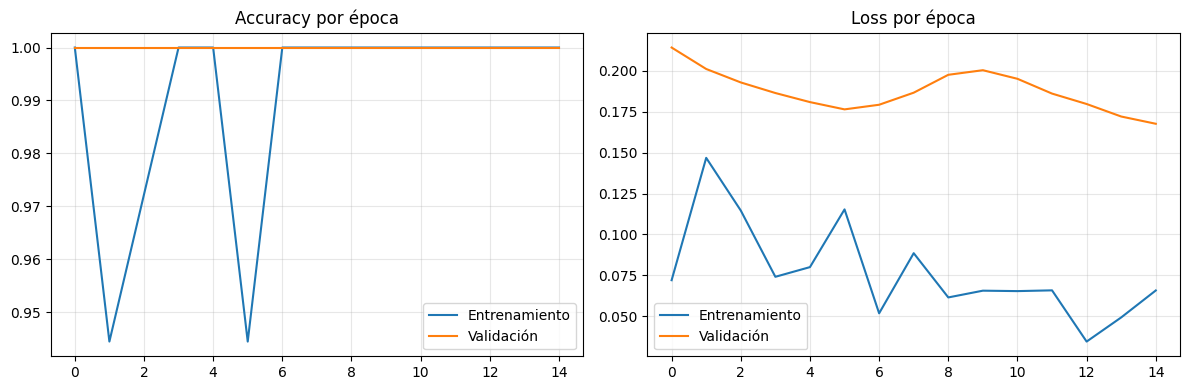

In [14]:
historia = modelo.fit(ds_train, validation_data=ds_val, epochs=15)

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(historia.history['accuracy'], label='Entrenamiento')
plt.plot(historia.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot(historia.history['loss'], label='Entrenamiento')
plt.plot(historia.history['val_loss'], label='Validación')
plt.title('Loss por época'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

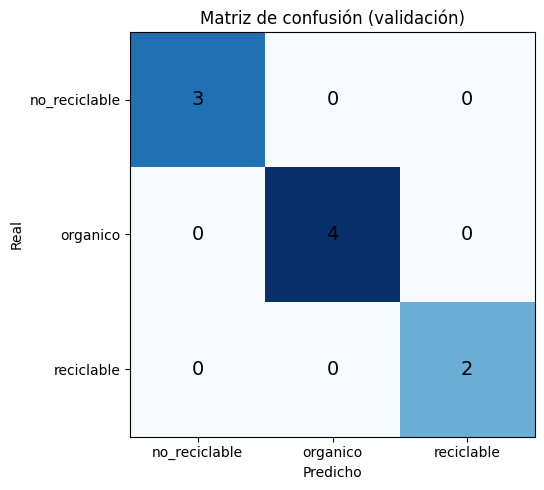

In [15]:
import numpy as np
ys_true, ys_pred = [], []
for imgs, labels in ds_val:
    preds = modelo.predict(imgs, verbose=0)
    ys_true.extend(labels.numpy())
    ys_pred.extend(np.argmax(preds, axis=1))

mat = tf.math.confusion_matrix(ys_true, ys_pred, num_classes=3).numpy()
plt.figure(figsize=(6,5))
plt.imshow(mat, cmap='Blues')
plt.title('Matriz de confusión (validación)')
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.xticks(range(3), clases); plt.yticks(range(3), clases)
for i in range(3):
    for j in range(3):
        plt.text(j, i, mat[i][j], ha='center', va='center', fontsize=14)
plt.tight_layout()
plt.show()

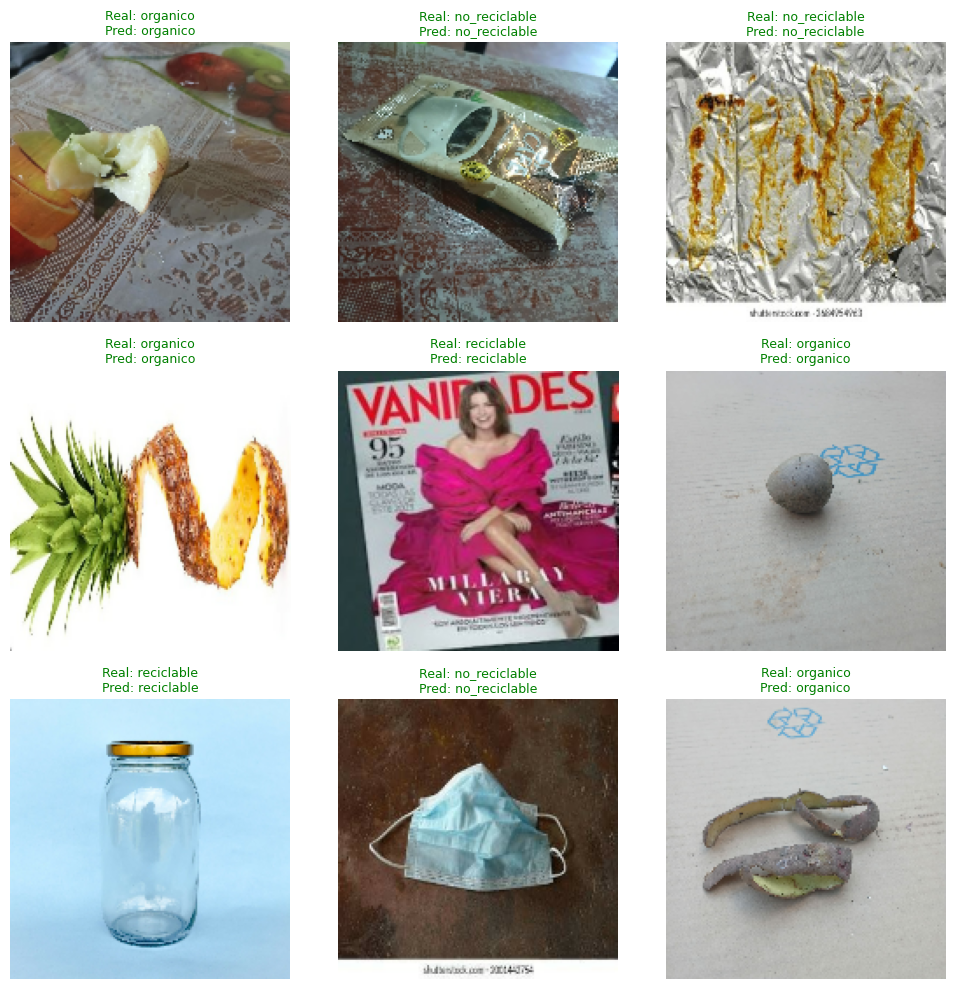

In [16]:
plt.figure(figsize=(10,10))
for imgs, labels in ds_val.take(1):
    preds = modelo.predict(imgs, verbose=0)
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow((imgs[i].numpy()+1)/2)
        p = np.argmax(preds[i]); r = labels[i].numpy()
        plt.title(f"Real: {clases[r]}\nPred: {clases[p]}",
                  color='green' if p==r else 'red', fontsize=9)
        plt.axis('off')
plt.tight_layout()
plt.show()